# The American Binomial Method in Theory and in Practice

**Rachmiel Klein's final project**

**Overview:** In this notebook, we first define American and European options. We discuss the Binomial tree method, then implement it for American options, along with implementing Black-Scholes, both extended to allow for dividends. We compare American options to Black-Scholes. We then implement the Binomial tree method for European options and compare the two, varying parameters such as divedinds, monyness, and time to expiration. We then compare each method to pricing in real historic market data.

# Introduction to American Options

An **American call option** is a contract between two parties, a buyer and a seller, that gives the buyer the right, but not the obligation, to buy an underlying asset from the seller for a predetermined price 
$K$, called the strike price at any time until a predetermined expiration date.

An **American put option** is a contract between two parties, a buyer and a seller, that gives the buyer the right, but not the obligation, to sell an underlying asset to the seller for a predetermined price 
$K$, called the strike price at any time until a predetermined expiration date.

European options are similar to American options, but the holder may only excersize the contract at the time of expiration, not before.

Suppose person A buys a call option from person B which expires in three months. If the option is American, then at any point in the span of those three months when the stock price is high enough, person A may excersize the contract and make a profit. For this reason, it is much more likely that person A will make a profit than if the option was European. For this reason, American options have much higher premiums.

In [1]:
# This block consists of all the packages we will use.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import norm
import yfinance as yf
import datetime
import time

sns.set_style('darkgrid')

# American Binomial Model for Option Pricing

## Overview

The **binomial model** is a discrete-time method for pricing options by modeling the evolution of a stock price over time. Instead of assuming continuous motion (as in Black–Scholes), the model assumes that at each time step the stock can move:

* **Up** by a factor $u$, or
* **Down** by a factor $d$

This creates a recombining tree of possible price paths. The option price is computed by working backward from maturity, using risk-neutral valuation and (for American options) optimal exercise decisions.

---

## Stock Price Dynamics

We divide the time to maturity $T$ into $N$ steps of size:

$$
\Delta t = \frac{T}{N}
$$

At each step:

$$
S \to
\begin{cases}
S \cdot u & \text{(up move)} \\
S \cdot d & \text{(down move)}
\end{cases}
$$

A common choice, which comes from the Cox–Ross–Rubinstein model, is:

$$
u = e^{\sigma \sqrt{\Delta t}}, \quad d = \frac{1}{u}
$$

where $\sigma$ is the volatility. This is a discretized version of Black-Scholes. Geometric Brownian motion of a stock occurs when $N$ limits to infinity.

---

## Risk-Neutral Probability

The binomial model enforces the absence of arbitrage by constructing a risk-neutral probability measure under which expected asset growth equals the risk-free rate, allowing option prices to be computed as discounted expected payoffs. Letting $r$ be the risk-free rate, the probability of an up move is:

$$
p = \frac{e^{(r - q)\Delta t} - d}{u - d}
$$

* $r$: risk-free rate
* $q$: dividend yield (optional; set $q=0$ if none)

---

## Stock Prices in the Tree

After $i$ steps with $j$ down moves:

$$
S_{j,i} = S_0 \cdot u^{i-j} \cdot d^{j}
$$

This works because the tree is recombining, so only the number of up and down moves matters, not their order. This is very similar to the formula for the probability of a binomial distributed random variable equaling a specific value.

---

## Terminal Payoff and Backward Induction

At maturity, the option value is its payoff.

* Call:
  $
  V_{j,N} = \max(S_{j,N} - K, 0)
  $

* Put:
  $
  V_{j,N} = \max(K - S_{j,N}, 0)
  $

Using this, we compute values backward through the tree using induction (recursion).

### Continuation Value

If we do **not** exercise, the value of the option is the discounted expected value after more jumps. Although the formula below looks like it is only the expected value for the next jump, the quantities $V_{j,i}$ are calculated recursively.

$$
\text{Continuation} = e^{-r\Delta t} \left( p V_{j,i+1} + (1-p) V_{j+1,i+1} \right)
$$

* $V_{j,i+1}$: value after an **up move**
* $V_{j+1,i+1}$: value after a **down move**

### Exercise value

If we **do** excersize when the stock's value is $S_{j,i}$, the value of the option, i.e. the excersize value is:

* Call: $\max(S_{j,i}-K,0)$
* Put: $\max(K-S_{j,i},0)$

---

### American Option Decision

Because American options can be excersized at any point before or at expiration, the option value is

$$
V_{j,i} = \max(\text{exercise value}, \text{continuation value})
$$

---

It is worth noting that because the Black-Scholes model has a closed form solution and this one does not, the algorithm for the binomial model is much slower (it is $O(N^2)$). 

# Implementation for American Options

We define a function returning the value of an American option using the binomial model. We also implement a modified version of the European Black-Scholes model to account for nonzero dividends.

In [2]:
# Below is a function which returns the value of an American option using the binomial model.

def american_option_binomial(S0,K,r,sigma,T,N,q=0,option_type="call"):
    # S0 is the initial stock price
    # K is the strike price
    # r is risk-free interest rate
    # T is time to expiration measured in years
    # N is the number of steps we will divide the time interval [0,T] into. Each step has length T/N
    # option_type defaults to "call", but if a different input is given, such as "put", the function returns the price of a put option
    
    dt = T/N # dt is the length of time of each step
    u = np.exp(sigma*np.sqrt(dt)) # up factor, i.e. the percentage increase of the stock at each step, using the Cox-Ross-Rubinstein model
    d = 1/u # down factor
    p = (np.exp((r-q)*dt)-d)/(u-d) # p can be thought of as the probability of an upward movement in a risk neutral world

    stock = np.zeros((N+1, N+1))
    option = np.zeros((N+1, N+1))

    # establish the tree
    for i in range(N+1):
        for j in range(i+1):
            # the [j,i]th entry is the price of the stock with i upward steps and j downward steps after i steps
            # this is a discrete approximation of geometric Brownian motion
            stock[j,i] = S0 * (u**(i-j)) * (d**j)

    # initialize the value of the option under each route in the tree
    if option_type == "call":
        option[:,N] = np.maximum(stock[:,N]-K,0)
    else:
        option[:,N] = np.maximum(K-stock[:,N],0)

    # work backwards through the tree, decide if better to excersize or hold the option
    for i in range(N-1,-1,-1):
        for j in range(i+1):

            # the expected future payoff from the option, assuming risk-neutral
            continuation = np.exp(-r*dt)*(p*option[j,i+1] + (1-p)*option[j+1,i+1])

            # amount of money the option is worth if you were to excersize it at that location in the tree
            if option_type=="call":
                exercise = max(stock[j,i]-K,0)
            else:
                exercise = max(K-stock[j,i],0)

            option[j,i] = max(exercise, continuation)

    # return the price of the option at the first node
    return option[0,0]

In [3]:
# Black-Scholes options pricing with continuous dividend yield

def bs(S0,K,sigma,T,r,q=0,option_type="call"):
    
    d1 = (np.log(S0/K)+(r-q+(0.5)*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "call":
        price = S0*np.exp(-q * T)*norm.cdf(d1) - np.exp(-r*T)*K*norm.cdf(d2)
        return price
    
    price = -S0*np.exp(-q * T)*norm.cdf(-d1) + np.exp(-r*T)*K*norm.cdf(-d2)
    return price

# American Binomial vs Black-Scholes

We run an initial comparison between the American binomial and Black-Scholes methods.

In [4]:
S0 = 250
K = 250
r = 0.038
sigma = 0.2
T = 1
N = 252
q = 0

print(f'The Black-Scholes price of a European option with these parameters is ${bs(S0,K,sigma,T,r,q,option_type = "call"):.2f}.')
print()
print(f'The Binomial method price of an American option with these parameters and {N} steps is ${american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call"):.2f}.')

The Black-Scholes price of a European option with these parameters is $24.55.

The Binomial method price of an American option with these parameters and 252 steps is $24.53.


### Interpretation
Both methods give similar prices. If early call is never excersized, then we would expect the American Binomial method to be a discrete version of Black-Scholes (with finitely many steps), which would explain why these prices are so similar. We will soon see that setting dividends higher makes these prices differ more.

We next plot the American Binomial method's price against the number of iterations $N$. We see that as $N\to\infty$, the price converges to the Black-Scholes price. One can change the parameters (leaving q = 0) and see that this remains true.

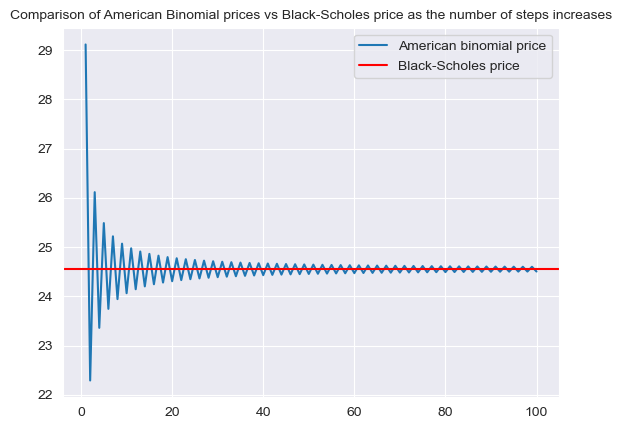

In [5]:
S0 = 250
K = 250
r = 0.038
sigma = 0.2
T = 1
q = 0

steps = range(1,101)
American_binomial_prices = [american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for N in steps]

plt.plot(steps,American_binomial_prices, label="American binomial price")
plt.axhline(y=bs(S0,K,sigma,T,r,q,option_type = "call"), color='r', label='Black-Scholes price')

plt.title(f'Comparison of American Binomial prices vs Black-Scholes price as the number of steps increases', size=10)
plt.legend()
plt.show()

In the graph above, we see that the American binomial method price converges by oscilation. This is due to a numeric error, but the true value seems to be Black-Scholes pricing. We next tweak the parameters so that q is high and observe that the American Binomial option is more expensive even when dividends are added to Black-Scholes. This suggests that under these parameters, it may be optimal to excersize before maturity.

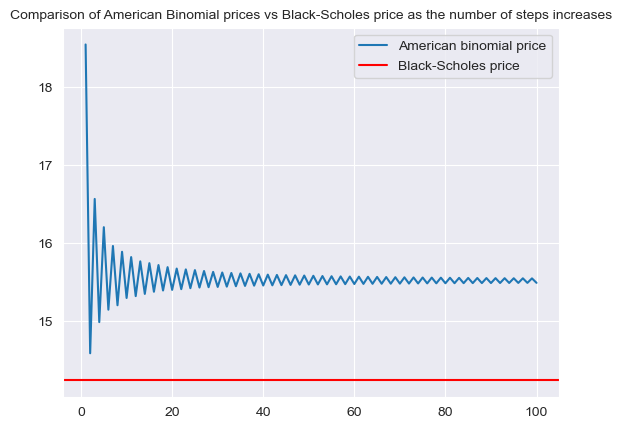

Black-Scholes price = $14.24.
American binomial price is between $15.55 and $15.49.


In [6]:
S0 = 250
K = 250
r = 0.038
sigma = 0.2
T = 1
q = 0.08

steps = range(1,101)
American_binomial_prices = [american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for N in steps]
bs_price = bs(S0,K,sigma,T,r,q,option_type = "call")

plt.plot(steps,American_binomial_prices, label="American binomial price")
plt.axhline(y=bs_price, color='r', label='Black-Scholes price')

plt.title(f'Comparison of American Binomial prices vs Black-Scholes price as the number of steps increases', size=10)
plt.legend()
plt.show()

print(f'Black-Scholes price = ${bs_price:.2f}.')
print(f'American binomial price is between ${American_binomial_prices[-2]:.2f} and ${American_binomial_prices[-1]:.2f}.')

We can get a much more acurate American estimate when $N$ is larger, but it comes at a time cost of $O(N^2)$:

In [7]:
N = 2_000
start_time = time.perf_counter()
USA_over = american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call")
USA_under = american_option_binomial(S0,K,r,sigma,T,N+1,q,option_type="call")
end_time = time.perf_counter()
print(f'American binomial price is between ${USA_over:.3f} and ${USA_under:.3f}. This took {end_time - start_time:.4f} seconds to compute.')
USA_average = 0.5 * (USA_over + USA_under)
print(f'The cost to excersize before maturity is approximately ${USA_average - bs_price:.3f}.')

American binomial price is between $15.510 and $15.513. This took 17.5806 seconds to compute.
The cost to excersize before maturity is approximately $1.273.


## When to excersize before maturity

We wish to see under what parameters the American binomial method andicipates early excersize. To do this, we code the "European equivalent" of the binomial method, i.e. the same code as the American function above without the early excersize. This is essentially the discrete version of the Black-Scholes method. While we could have kept compairing American binomial to Black-Scholes, we wish to compare convergences as $N$ gets large.

In [8]:
def european_option_binomial(S0,K,r,sigma,T,N,q=0,option_type="call"):
    # S0 is the initial stock price
    # K is the strike price
    # r is risk-free interest rate
    # T is time to expiration measured in years
    # N is the number of steps we will divide the time interval [0,T] into. Each step has length T/N
    # option_type defaults to "call", but if a different input is given, such as "put", the function returns the price of a put option
    
    dt = T/N
    u = np.exp(sigma*np.sqrt(dt))
    d = 1/u
    p = (np.exp((r-q)*dt)-d)/(u-d)

    stock = np.zeros((N+1, N+1))
    option = np.zeros((N+1, N+1))

    # establish the tree
    for i in range(N+1):
        for j in range(i+1):
            stock[j,i] = S0 * (u**(i-j)) * (d**j)

    # initialize the value of the option under each route in the tree
    if option_type == "call":
        option[:,N] = np.maximum(stock[:,N]-K,0)
    else:
        option[:,N] = np.maximum(K-stock[:,N],0)

    # work backwards through the tree to calculate the value of the option at each point in time (no early excersize).
    for i in range(N-1,-1,-1):
        for j in range(i+1):
            
            # the expected future payoff from the option, assuming risk-neutral
            continuation = np.exp(-r*dt)*(p*option[j,i+1] + (1-p)*option[j+1,i+1])

            option[j,i] = continuation

    # return the price of the option at the first node
    return option[0,0]

In [9]:
# The following is the difference between the American price, when early excersize is allowed, and the European price, when it is not.
# This function can be thought of as the early excersize premium, the price that the ability to early excersize costs.

def early_excersize_premium(S0,K,r,sigma,T,N,q=0,option_type="call"):
    return american_option_binomial(S0,K,r,sigma,T,N,q,option_type) - european_option_binomial(S0,K,r,sigma,T,N,q,option_type)

### The effect of dividends
At first, one may expect that early excersize will be optimal if the call is deep in the money and there is a low time to expiration, but it turns out that dividends must also be nonzero. Suppose that a call is deep in the money and there is a low time to expiration and zero dividends. Because options have a time value, there is no point in early excersize, because the stock may go up in the fututre. Conversely, if dividends are nonzero, then the stock is expected to drop on the ex-dividend date, and it may be optimal to excersize before that date.

In [10]:
# Suppose the call is deep in the money and dividends are zero.

S0 = 200
K = 100
r = 0.038
sigma = 0.2
T = 1
N = 252
q = 0.00

print(f'The early excersize premium with q = {q}  is ${early_excersize_premium(S0,K,r,sigma,T,N,q,option_type="call"):.2f}.')

# Now suppose that dividends are nonzero, say 2%.

q = 0.02

print(f'The early excersize premium with q = {q} is ${early_excersize_premium(S0,K,r,sigma,T,N,q,option_type="call"):.2f}.')

The early excersize premium with q = 0.0  is $0.00.
The early excersize premium with q = 0.02 is $0.28.


---

We investigate this behavior more closely by plotting behavior as $q$ varies from $0$ to $0.5$. We first assume that the option is at the money (ATM) and the time to expiration is one year.

---

In [11]:
S0 = 250
K = 250
r = 0.038
sigma = 0.2
T = 1
N = 252

q_steps = np.linspace(0,0.5,51)

american_premiums = np.array([american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps])

european_premiums = np.array([european_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps])

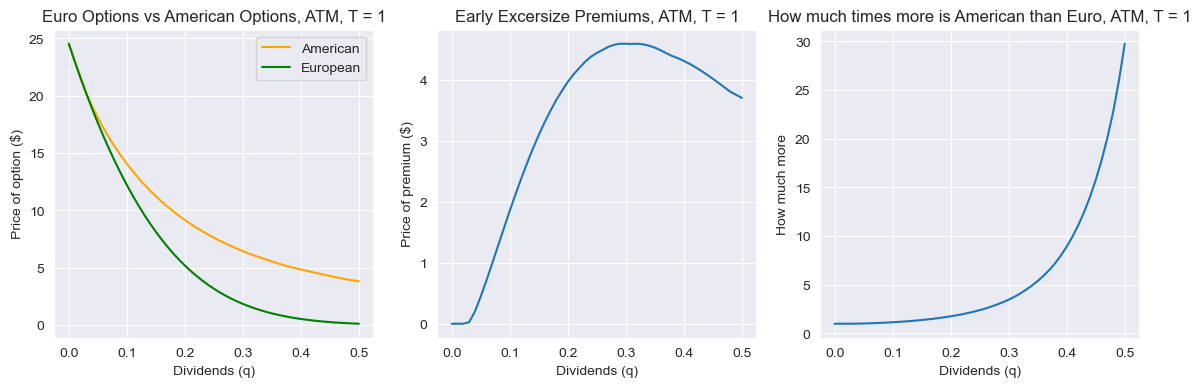

In [12]:
fig,axes = plt.subplots(1,3, figsize = (14,4))

# In the left graph, we plot American vs European option prices.
axes[0].plot(q_steps, american_premiums, color = "orange", label = "American")
axes[0].plot(q_steps, european_premiums, color = "green", label = "European")
axes[0].set_title("Euro Options vs American Options, ATM, T = 1")
axes[0].set_xlabel("Dividends (q)")
axes[0].set_ylabel("Price of option ($)")
axes[0].legend()

# In the middle graph, we plot the early excersize premiums.
early_ex_premiums = american_premiums - european_premiums

axes[1].plot(q_steps, early_ex_premiums)
axes[1].set_title("Early Excersize Premiums, ATM, T = 1")
axes[1].set_xlabel("Dividends (q)")
axes[1].set_ylabel("Price of premium ($)")

# In the right graph, we plot the multiplier for how much more expensive an option got once adding the early excersize premium.
early_ex_percent_change_rel_euro = american_premiums / european_premiums

axes[2].plot(q_steps, early_ex_percent_change_rel_euro)
axes[2].set_title("How much times more is American than Euro, ATM, T = 1")
axes[2].set_xlabel("Dividends (q)")
axes[2].set_ylabel("How much more")

plt.show()

From the left plot we see that while both option prices decrease (presumably because higher dividends imply that the stock has more drastic decreases), the American option remains more expensive. The middle plot shows the difference between the orange and the green line. Note that the early excersize premium drops starting around q = 0.3. This is because if dividends are too high, the stocks are worth less. Nevertheless, from the right hand plot, we see that as dividends increase, American options become exponentially more expensive than the European counterpart.

---

We next vary the moneyness of the option.

In [13]:
S0 = 250
r = 0.038
sigma = 0.2
T = 1
N = 252
q_steps = np.linspace(0,0.5,51)
all_Ks = [300,270,210,180]

american_premiums_list = [np.array([american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps]) for K in all_Ks]
european_premiums_list = [np.array([european_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps]) for K in all_Ks]

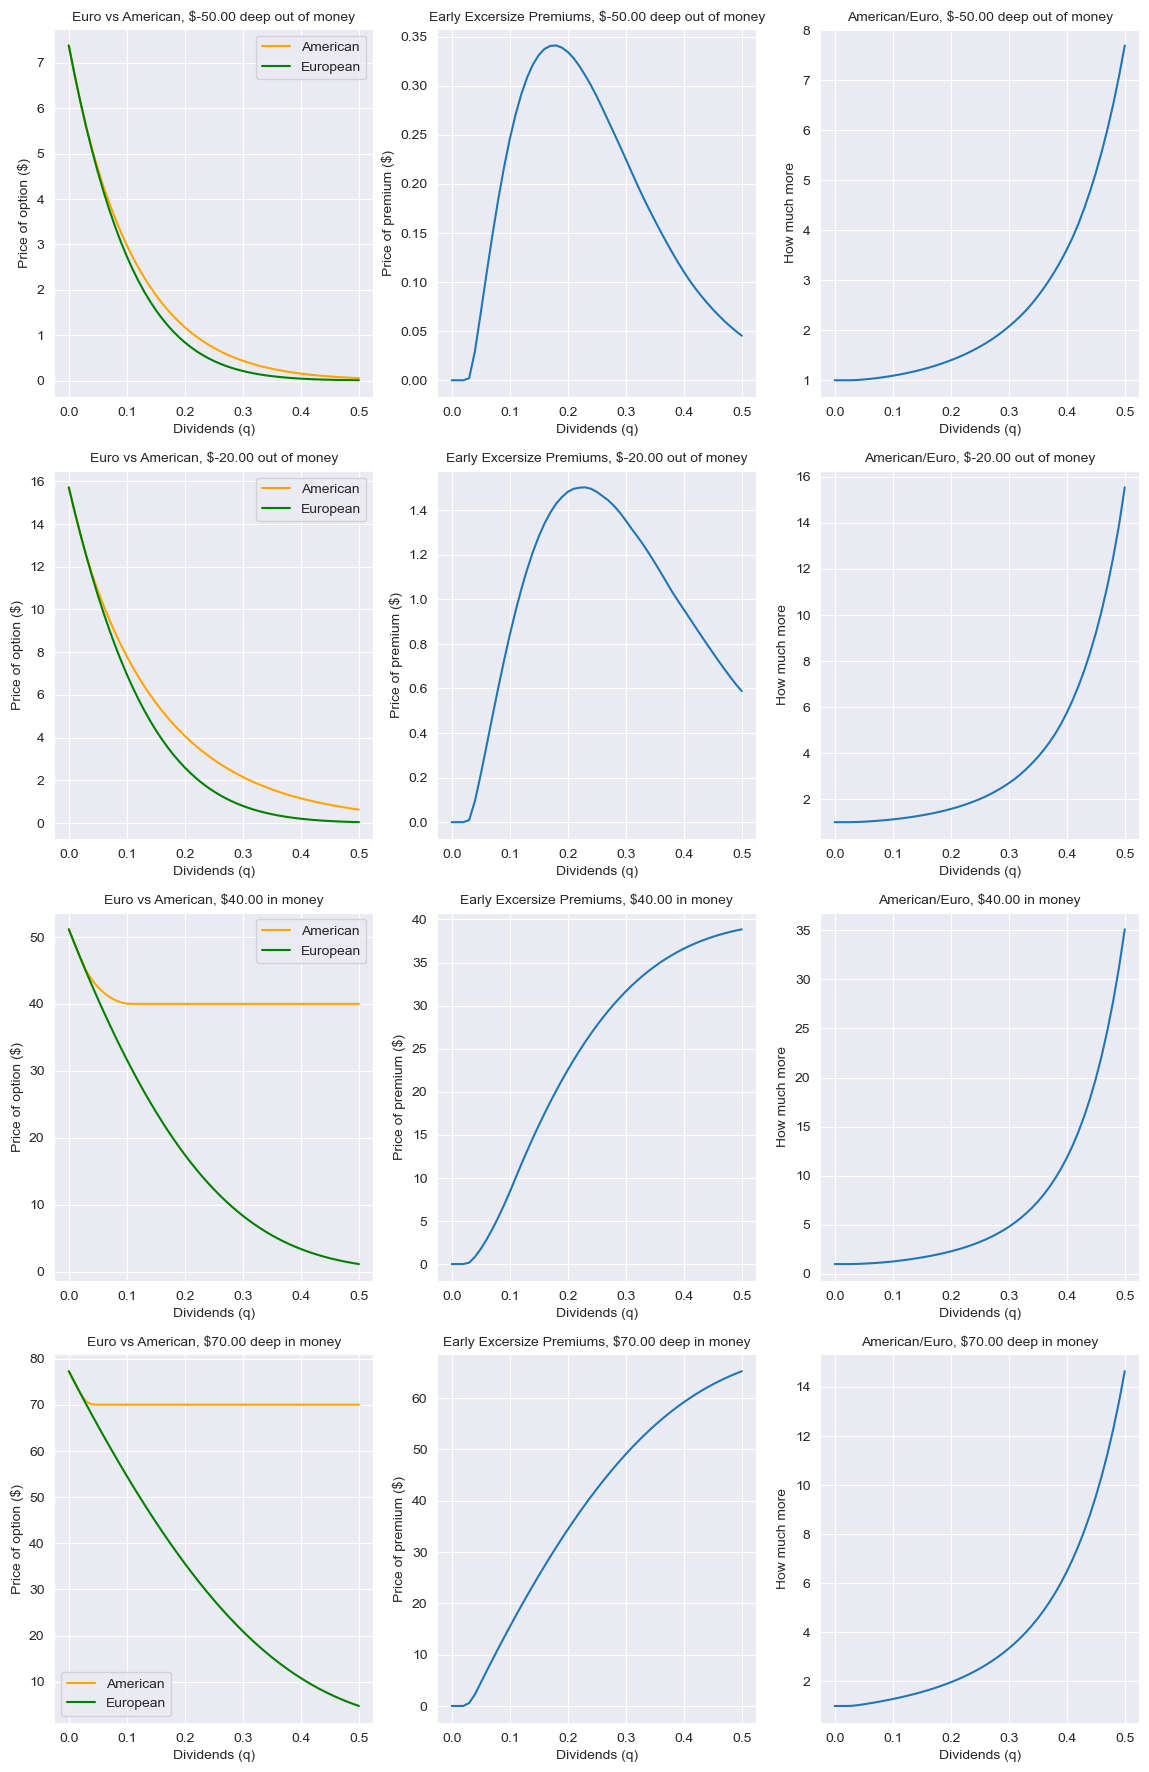

In [14]:
fig,axes = plt.subplots(len(all_Ks),3, figsize = (14,22))

descriptions = ["deep out of money", "out of money", "in money", "deep in money"]

for i in range(len(all_Ks)):

    # In the left graph, we plot American vs European option prices.
    axes[i,0].plot(q_steps, american_premiums_list[i], color = "orange", label = "American")
    axes[i,0].plot(q_steps, european_premiums_list[i], color = "green", label = "European")
    axes[i,0].set_title(f"Euro vs American, ${S0 - all_Ks[i]:.2f} {descriptions[i]}", fontsize = 10)
    axes[i,0].set_xlabel("Dividends (q)")
    axes[i,0].set_ylabel("Price of option ($)")
    axes[i,0].legend()

    # In the middle graph, we plot the early excersize premiums.
    early_ex_premiums = american_premiums_list[i] - european_premiums_list[i]

    axes[i,1].plot(q_steps, early_ex_premiums)
    axes[i,1].set_title(f"Early Excersize Premiums, ${S0 - all_Ks[i]:.2f} {descriptions[i]}", fontsize = 10)
    axes[i,1].set_xlabel("Dividends (q)")
    axes[i,1].set_ylabel("Price of premium ($)")

    # In the right graph, we plot the multiplier for how much more expensive an option got once adding the early excersize premium.
    early_ex_percent_change_rel_euro = american_premiums_list[i] / european_premiums_list[i]

    axes[i,2].plot(q_steps, early_ex_percent_change_rel_euro)
    axes[i,2].set_title(f"American/Euro, ${S0 - all_Ks[i]:.2f} {descriptions[i]}", fontsize = 10)
    axes[i,2].set_xlabel("Dividends (q)")
    axes[i,2].set_ylabel("How much more")

plt.show()

The center graphs all taper at a point, but the deeper in the money, the longer it takes to taper. As for the left hand graphs, we observe that as $q$ increases,
$$
\text{American Option Price}\to\max\{S_0-K,0\}.
$$
The European option, on the other hand, approaches zero.

In [15]:
S0 = 250
K = 250
r = 0.038
sigma = 0.2
N = 252
q_steps = np.linspace(0,0.5,51)
all_Ts = [0.25, 0.75, 1, 2, 5]

american_premiums_list = [np.array([american_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps]) for T in all_Ts]
european_premiums_list = [np.array([european_option_binomial(S0,K,r,sigma,T,N,q,option_type="call") for q in q_steps]) for T in all_Ts]

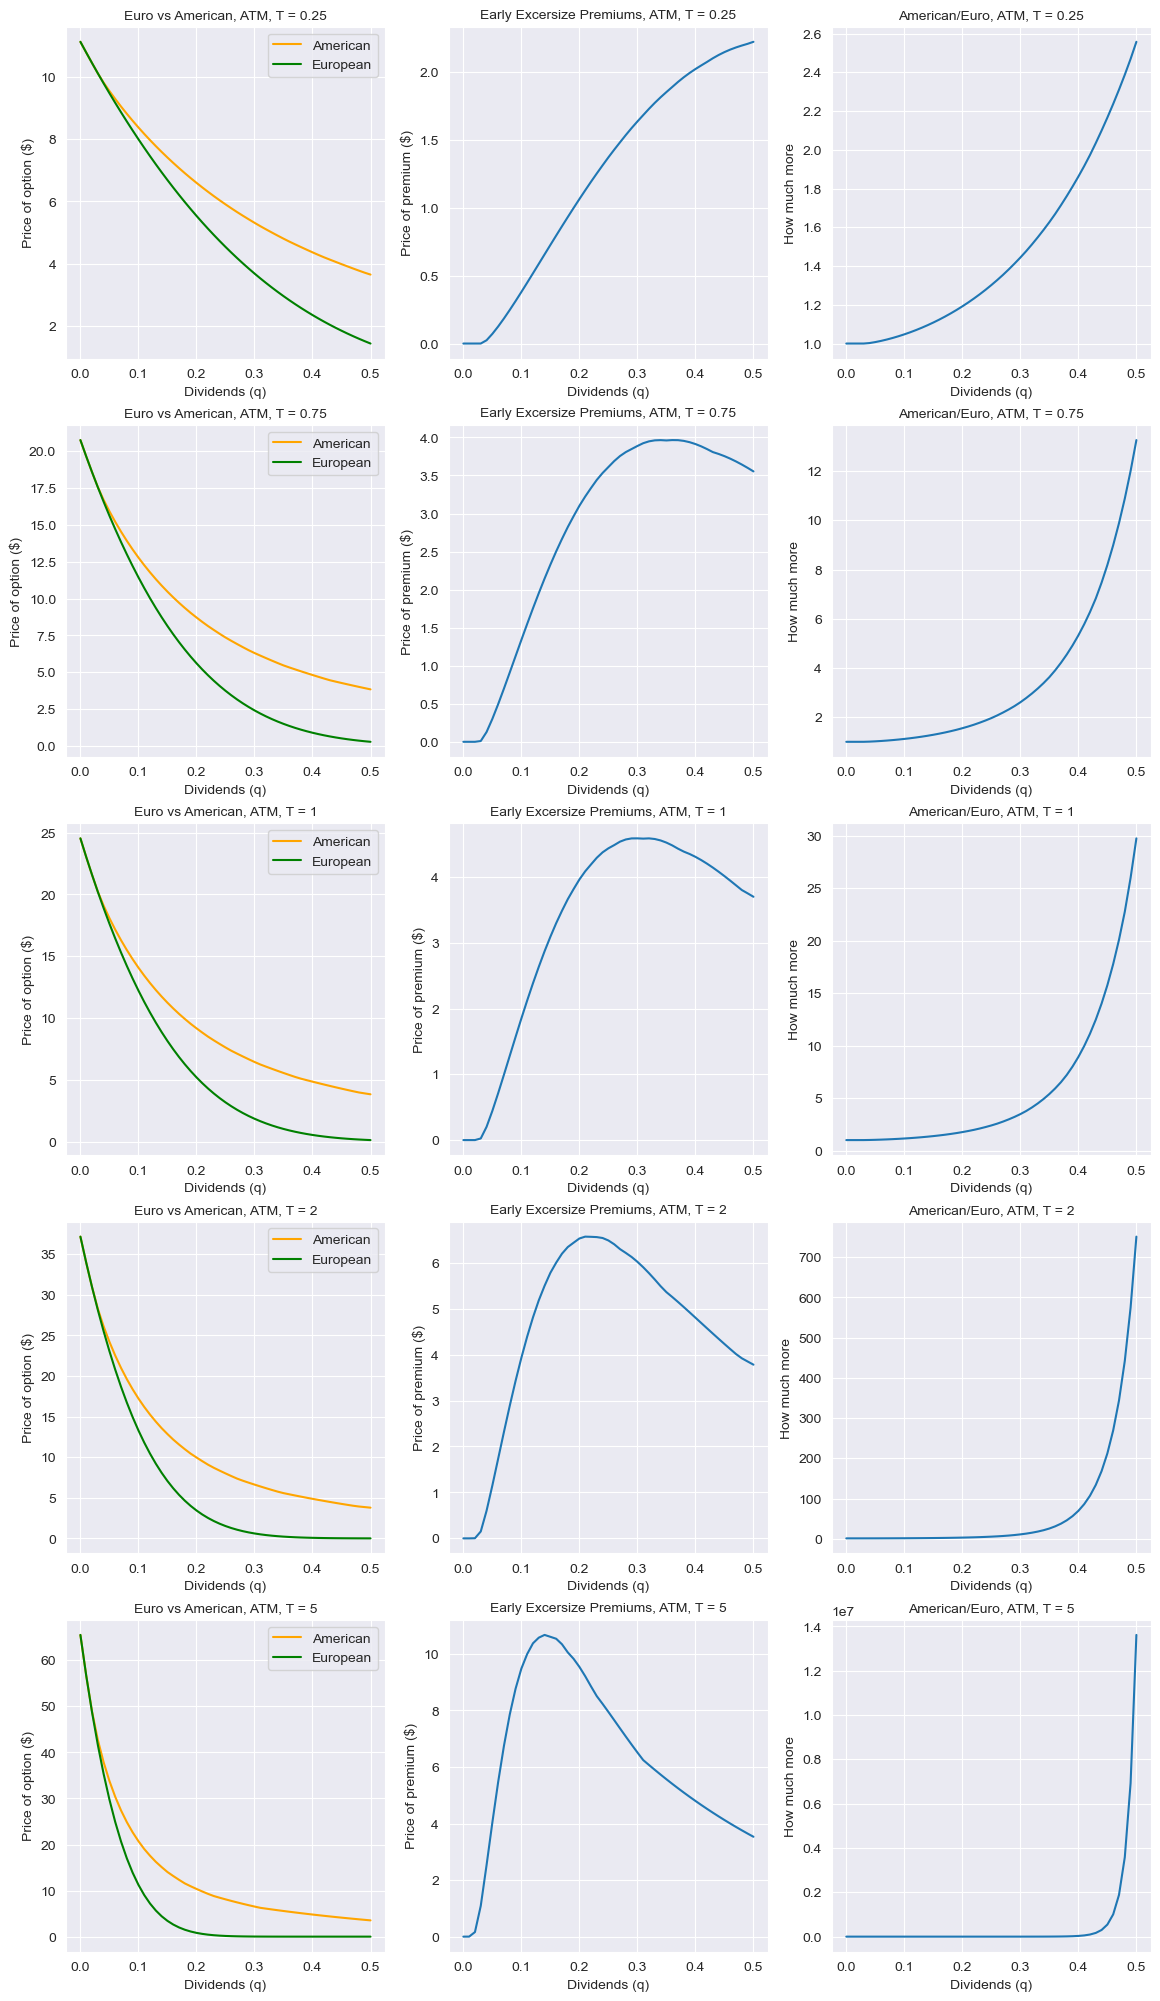

In [16]:
fig,axes = plt.subplots(len(all_Ts),3, figsize = (14,25))

for i in range(len(all_Ts)):
    
    # In the left graph, we plot American vs European option prices.
    axes[i,0].plot(q_steps, american_premiums_list[i], color = "orange", label = "American")
    axes[i,0].plot(q_steps, european_premiums_list[i], color = "green", label = "European")
    axes[i,0].set_title(f"Euro vs American, ATM, T = {all_Ts[i]}", fontsize = 10)
    axes[i,0].set_xlabel("Dividends (q)")
    axes[i,0].set_ylabel("Price of option ($)")
    axes[i,0].legend()

    # In the middle graph, we plot the early excersize premiums.
    early_ex_premiums = american_premiums_list[i] - european_premiums_list[i]

    axes[i,1].plot(q_steps, early_ex_premiums)
    axes[i,1].set_title(f"Early Excersize Premiums, ATM, T = {all_Ts[i]}", fontsize = 10)
    axes[i,1].set_xlabel("Dividends (q)")
    axes[i,1].set_ylabel("Price of premium ($)")

    # In the right graph, we plot the multiplier for how much more expensive an option got once adding the early excersize premium.
    early_ex_percent_change_rel_euro = american_premiums_list[i] / european_premiums_list[i]

    axes[i,2].plot(q_steps, early_ex_percent_change_rel_euro)
    axes[i,2].set_title(f"American/Euro, ATM, T = {all_Ts[i]}", fontsize = 10)
    axes[i,2].set_xlabel("Dividends (q)")
    axes[i,2].set_ylabel("How much more")


plt.show()

# Comparing Binomial American Option Prices to Market Data

## Overview

In this section, we compare prices from the **American binomial model** to real market option prices. A key challenge is that market prices are not based on historical volatility, but on **implied volatility**—the volatility parameter that makes a model match observed prices.

We will:

1. Download real option data
2. Extract implied volatilities
3. Price options using the binomial model
4. Compare model prices to market prices

## Step 1: Load Market Data

In [17]:
ticker = yf.Ticker("AAPL")

# Get available expirations
expirations = ticker.options
expiry = expirations[0]

opt_chain = ticker.option_chain(expiry)
calls = opt_chain.calls

## Step 2: Extract Inputs

We need:

* Current stock price $S_0$
* Time to maturity $T$
* Risk-free interest rate $r$
* Dividend rate $q$
* Implied volutility $\sigma$
* Strikes $K$
* Actual prices of options to compare
* American binomial prices under the parameters

In [18]:
# S0
S0 = ticker.history(period="1d")['Close'].iloc[-1]

# T
today = datetime.datetime.today()
expiry_date = datetime.datetime.strptime(expiry, "%Y-%m-%d")
T = (expiry_date - today).days / 365

# Risk-free rate based on 10-year US Treasury yield at approximately 4.30%
r = 0.043

# q
q = ticker.info.get("dividendYield", 0)

## Step 3: Compute Binomial Prices

We use the implied volatility from the market for each option.

In [ ]:
all_Ks = []
model_prices = []
market_prices = []

N = 252  # number of binomial steps

for _, row in calls.iterrows():
    K = row['strike']
    sigma = row['impliedVolatility']
    market_price = row['lastPrice']
    
    if np.isnan(sigma) or np.isnan(market_price):
        continue
    
    model_price = american_option_binomial(S0, K, r, sigma, T, N, q, option_type="call")
    
    all_Ks.append(K)
    market_prices.append(market_price)
    model_prices.append(model_price)

C:\Users\rachm\AppData\Local\Temp\ipykernel_20960\3243714709.py:14: RuntimeWarning: invalid value encountered in scalar divide
  p = (np.exp((r-q)*dt)-d)/(u-d) # p can be thought of as the probability of an upward movement in a risk neutral world


## Step 4: Compairing Market and Model Prices

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(all_Ks, market_prices, label="Market Prices")
plt.scatter(all_Ks, model_prices, label="Binomial Model", alpha=0.5)

plt.xlabel("Strike Price")
plt.ylabel("Option Price")
plt.title(fr"Market vs Binomial American Option Prices for AAPL, $S_0$ = \${S0:.2f}")
plt.legend()
plt.show()

## Step 5: Pricing Error

In [ ]:
errors = np.array(market_prices) - np.array(model_prices)

plt.figure(figsize=(6,5))
plt.scatter(all_Ks, errors)
plt.axhline(0, color='red')

plt.xlabel("Strike Price")
plt.ylabel("How Much More was Market than Model")
plt.title("Pricing Error Across Strikes for AAPL")
plt.show()

## Interpretation

Although the binomial model does not perfectly match market prices even when using implied volatility, the model matches the historic data more so when the strike price is higher and when the option is worth less.